In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [50]:
data = {
    'Area_m2': [45, 60, 30, 100, 85, 55, 120, 40],
    'Rooms': [2, 2, 1, 4, 3, 2, 5, 1],
    'District': ['Mitte', 'Pankow', 'Neukölln', 'Charlottenburg', 'Wedding', 'Mitte', 'Zehlendorf', 'Friedrichshain'],
    'Year': [1910, 1960, 1920, 2015, 1980, 1905, 2020, 1995],
    'Price_Euro': [350000, 320000, 195000, 850000, 410000, 420000, 1100000, 280000]
}

df = pd.DataFrame(data)
print("Berlin Apartment Sample:")
print(df.head())

Berlin Apartment Sample:
   Area_m2  Rooms        District  Year  Price_Euro
0       45      2           Mitte  1910      350000
1       60      2          Pankow  1960      320000
2       30      1        Neukölln  1920      195000
3      100      4  Charlottenburg  2015      850000
4       85      3         Wedding  1980      410000


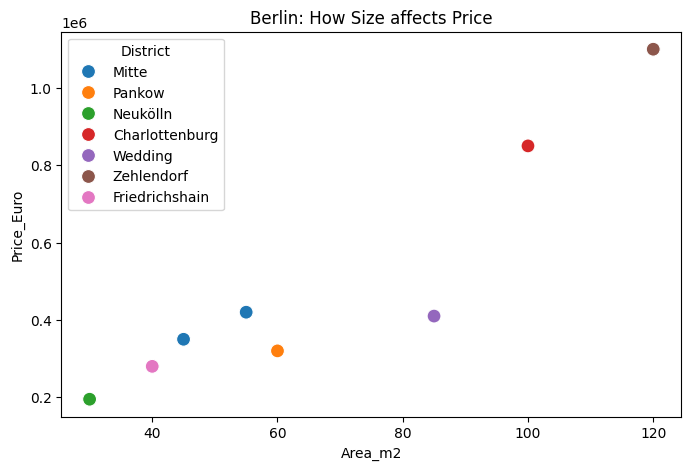

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Area_m2', y='Price_Euro', hue='District', s=100)
plt.title("Berlin: How Size affects Price")
plt.show()

In [ ]:
X = df[['Area_m2', 'Rooms']]
y = df['Price_Euro']
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X, y)
test_apartment = [[70, 3]]
predicted_price = reg_model.predict(test_apartment)

print(f"Predicted Price for 70m2, 3-room apartment: €{predicted_price[0]:,.2f}")

Predicted Price for 70m2, 3-room apartment: €367,900.00


c:\Users\ragha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
categorical_features = ['District']
numerical_features = ['Area_m2', 'Rooms', 'Year']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough')
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
X = df[['Area_m2', 'Rooms', 'Year', 'District']]
y = df['Price_Euro']
model_pipeline.fit(X, y)

print("Model trained with location data!")

Model trained with location data!


In [ ]:
apt_mitte = pd.DataFrame([[60, 2, 1960, 'Mitte']], columns=X.columns)
apt_pankow = pd.DataFrame([[60, 2, 1960, 'Pankow']], columns=X.columns)
price_1 = model_pipeline.predict(apt_mitte)
price_2 = model_pipeline.predict(apt_pankow)
print(f"Price in Mitte: €{price_1[0]:,.0f}")
print(f"Price in Pankow: €{price_2[0]:,.0f}")
print(f"Difference: €{abs(price_1[0] - price_2[0]):,.0f}")

Price in Mitte: €368,450
Price in Pankow: €338,050
Difference: €30,400


In [24]:
X = df[['Area_m2', 'Rooms', 'Year', 'District']]
y_pred = model_pipeline.predict(X)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"Mean Absolute Error: €{mae:,.2f}")
print(f"Model Accuracy (R2 Score): {r2:.2f}")

Mean Absolute Error: €55,937.50
Model Accuracy (R2 Score): 0.93


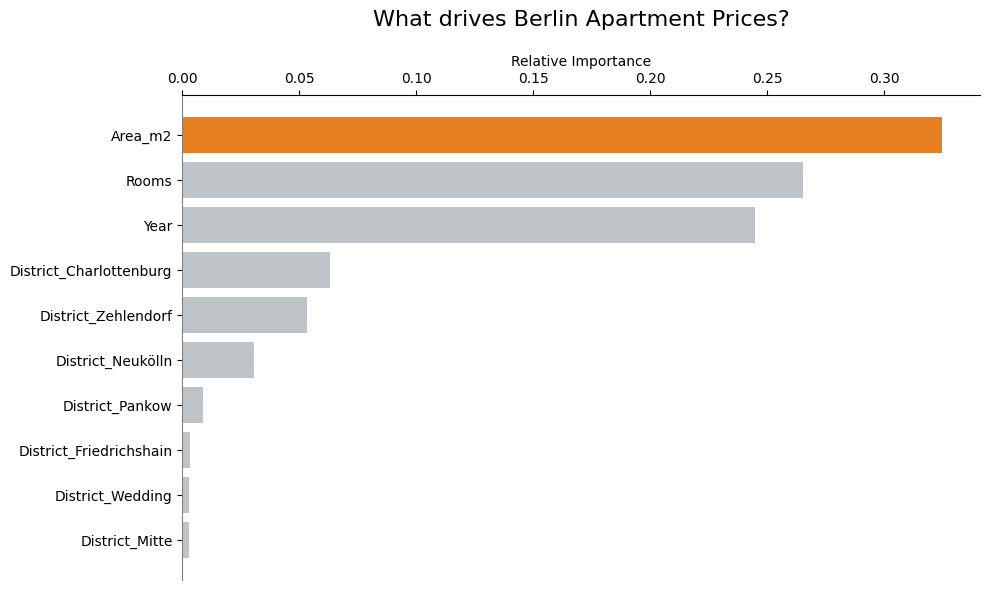

In [45]:
highlight_color = '#e67e22'
neutral_color = '#bdc3c7'
ohe_features = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out()
all_features = np.concatenate([ohe_features, numerical_features])
importances = model_pipeline.named_steps['regressor'].feature_importances_
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)
colors = [neutral_color] * (len(importances) - 1) + [highlight_color]
plt.barh(range(len(indices)), importances[indices], align='center',color=colors)
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('What drives Berlin Apartment Prices?',pad=50,fontsize=16)
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('gray')
plt.gca().spines['bottom'].set_visible(False)
ax=plt.gca()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()